# IS 4487 Assignment 9: Customer Segmentation with Clustering

In this assignment, you will:
- Apply unsupervised learning to explore patterns in hotel booking behavior
- Use K-Means and Gaussian Mixture Models (GMM) for customer segmentation
- Evaluate model quality with metrics like Silhouette Score and Davies-Bouldin Index
- Connect clustering to actionable business insights

## Why This Matters

Businesses like hotels and travel platforms (e.g., Airbnb or Expedia) rely on customer segmentation to tailor promotions, pricing strategies, and service levels. Unlike supervised models, clustering helps uncover patterns when no labels exist—an ideal tool when entering new markets or analyzing unstructured customer behavior.

<a href="https://colab.research.google.com/github/Stan-Pugsley/is_4487_base/blob/main/Assignments/assignment_09_clustering.ipynb" target="_parent">
  <img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/>
</a>


## Dataset Description: Hotel Bookings

This dataset contains booking information for two types of hotels: a **city hotel** and a **resort hotel**. Each record corresponds to a single booking and includes various details about the reservation, customer demographics, booking source, and whether the booking was canceled.

**Source**: [GitHub - TidyTuesday: Hotel Bookings](https://github.com/rfordatascience/tidytuesday/blob/master/data/2020/2020-02-11/readme.md)

### Key Use Cases
- Understand customer booking behavior
- Explore factors related to cancellations
- Segment guests based on booking characteristics
- Compare city vs. resort hotel performance

### Data Dictionary

| Variable | Type | Description |
|----------|------|-------------|
| `hotel` | character | Hotel type: City or Resort |
| `is_canceled` | integer | 1 = Canceled, 0 = Not Canceled |
| `lead_time` | integer | Days between booking and arrival |
| `arrival_date_year` | integer | Year of arrival |
| `arrival_date_month` | character | Month of arrival |
| `stays_in_weekend_nights` | integer | Nights stayed on weekends |
| `stays_in_week_nights` | integer | Nights stayed on weekdays |
| `adults` | integer | Number of adults |
| `children` | integer | Number of children |
| `babies` | integer | Number of babies |
| `meal` | character | Type of meal booked |
| `country` | character | Country code of origin |
| `market_segment` | character | Booking source (e.g., Direct, Online TA) |
| `distribution_channel` | character | Booking channel used |
| `is_repeated_guest` | integer | 1 = Repeated guest, 0 = New guest |
| `previous_cancellations` | integer | Past booking cancellations |
| `previous_bookings_not_canceled` | integer | Past bookings not canceled |
| `reserved_room_type` | character | Initially reserved room type |
| `assigned_room_type` | character | Room type assigned at check-in |
| `booking_changes` | integer | Number of booking modifications |
| `deposit_type` | character | Deposit type (No Deposit, Non-Refund, etc.) |
| `agent` | character | Agent ID who made the booking |
| `company` | character | Company ID (if booking through company) |
| `days_in_waiting_list` | integer | Days on the waiting list |
| `customer_type` | character | Booking type: Contract, Transient, etc. |
| `adr` | float | Average Daily Rate (price per night) |
| `required_car_parking_spaces` | integer | Requested parking spots |
| `total_of_special_requests` | integer | Number of special requests made |
| `reservation_status` | character | Final status (Canceled, No-Show, Check-Out) |
| `reservation_status_date` | date | Date of the last status update |

This dataset is ideal for classification, segmentation, and trend analysis exercises.

## 1. Setup and Load Data

### Business framing:  

### Do the following:
Before we can cluster or segment anything, we need clean, accessible data in a usable format.

- Import the necessary Python libraries
- Import data from the hotels dataset into a dataframe (in GitHub go to the DataSets folder and look for `hotels.csv`)
- Display the first few rows

### In Your Response:
1. What stands out in the initial preview? Any columns or rows that seem unusual?

In [16]:
# Add code here
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sklearn
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.mixture import GaussianMixture
df = pd.read_csv("hotels.csv")

pd.read_csv("hotels.csv")


,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,...,deposit_type,agent,company,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date
0,Resort Hotel,0,342,2015,July,27,1,0,0,2,...,No Deposit,NaN,NaN,0,Transient,0.00,0,0,Check-Out,2015-07-01
1,Resort Hotel,0,737,2015,July,27,1,0,0,2,...,No Deposit,NaN,NaN,0,Transient,0.00,0,0,Check-Out,2015-07-01
2,Resort Hotel,0,7,2015,July,27,1,0,1,1,...,No Deposit,NaN,NaN,0,Transient,75.00,0,0,Check-Out,2015-07-02
3,Resort Hotel,0,13,2015,July,27,1,0,1,1,...,No Deposit,304.0,NaN,0,Transient,75.00,0,0,Check-Out,2015-07-02
4,Resort Hotel,0,14,2015,July,27,1,0,2,2,...,No Deposit,240.0,NaN,0,Transient,98.00,0,1,Check-Out,2015-07-03
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
119385,City Hotel,0,23,2017,August,35,30,2,5,2,...,No Deposit,394.0,NaN,0,Transient,96.14,0,0,Check-Out,2017-09-06
119386,City Hotel,0,102,2017,August,35,31,2,5,3,...,No Deposit,9.0,NaN,0,Transient,225.43,0,2,Check-Out,2017-09-07
119387,City Hotel,0,34,2017,August,35,31,2,5,2,...,No Deposit,9.0,NaN,0,Transient,157.71,0,4,Check-Out,2017-09-07
119388,City Hotel,0,109,2017,August,35,31,2,5,2,...,No Deposit,89.0,NaN,0,Transient,104.40,0,0,Check-Out,2017-09-07


### ✍️ Your Response: 🔧
1. Agent coloumn has a lot of null values and numerical values which to me doesnt make sense or tell me anything. There is also a numerical column called ADR which I am not totally aware what that means, a name change might provide clarity to myself and others analyzing the data.

## 2. Select and Prepare Features

### Business framing:  

A hotel might want to group guests based on how long they stay, how far in advance they book, or how likely they are to make special requests. You need to pick variables that represent meaningful guest behavior.

### Do the following:
- Choose 3–5 numeric features related to customer behavior
- Drop missing values if needed
- Standardize using `StandardScaler`

### In Your Response:
1. What features did you select and why?
2. What kinds of patterns or segments do you expect to find?


In [18]:
# Define the new set of features to select
selected_features = ['days_in_waiting_list', 'adults', 'stays_in_week_nights', 'stays_in_weekend_nights']
df
features_df.dropna(inplace=True)
df.describe()

,is_canceled,lead_time,arrival_date_year,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,children,babies,is_repeated_guest,previous_cancellations,previous_bookings_not_canceled,booking_changes,agent,company,days_in_waiting_list,adr,required_car_parking_spaces,total_of_special_requests
count,119390.000000,119390.000000,119390.000000,119390.000000,119390.000000,119390.000000,119390.000000,119390.000000,119386.000000,119390.000000,119390.000000,119390.000000,119390.000000,119390.000000,103050.000000,6797.000000,119390.000000,119390.000000,119390.000000,119390.000000
mean,0.370416,104.011416,2016.156554,27.165173,15.798241,0.927599,2.500302,1.856403,0.103890,0.007949,0.031912,0.087118,0.137097,0.221124,86.693382,189.266735,2.321149,101.831122,0.062518,0.571363
std,0.482918,106.863097,0.707476,13.605138,8.780829,0.998613,1.908286,0.579261,0.398561,0.097436,0.175767,0.844336,1.497437,0.652306,110.774548,131.655015,17.594721,50.535790,0.245291,0.792798
min,0.000000,0.000000,2015.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,6.000000,0.000000,-6.380000,0.000000,0.000000
25%,0.000000,18.000000,2016.000000,16.000000,8.000000,0.000000,1.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,9.000000,62.000000,0.000000,69.290000,0.000000,0.000000
50%,0.000000,69.000000,2016.000000,28.000000,16.000000,1.000000,2.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,14.000000,179.000000,0.000000,94.575000,0.000000,0.000000
75%,1.000000,160.000000,2017.000000,38.000000,23.000000,2.000000,3.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,229.000000,270.000000,0.000000,126.000000,0.000000,1.000000
max,1.000000,737.000000,2017.000000,53.000000,31.000000,19.000000,50.000000,55.000000,10.000000,10.000000,1.000000,26.000000,72.000000,21.000000,535.000000,543.000000,391.000000,5400.000000,8.000000,5.000000


In [20]:
# Define the features to be used for clustering
selected_features = ['days_in_waiting_list', 'adults', 'stays_in_week_nights', 'stays_in_weekend_nights']
features_for_scaling = hotels[selected_features].copy()
features_for_scaling.dropna(inplace=True)
scaler = StandardScaler()
scaled_features_array = scaler.fit_transform(features_for_scaling)
scaled_features_df = pd.DataFrame(scaled_features_array, columns=selected_features)
print("First 5 rows of the scaled features:")
display(scaled_features_df.head())
print("\nSummary statistics of the scaled features:")
display(scaled_features_df.describe())

First 5 rows of the scaled features:


,days_in_waiting_list,adults,stays_in_week_nights,stays_in_weekend_nights
0,-0.131924,0.247897,-1.310240,-0.92889
1,-0.131924,0.247897,-1.310240,-0.92889
2,-0.131924,-1.478447,-0.786207,-0.92889
3,-0.131924,-1.478447,-0.786207,-0.92889
4,-0.131924,0.247897,-0.262174,-0.92889



Summary statistics of the scaled features:


,days_in_waiting_list,adults,stays_in_week_nights,stays_in_weekend_nights
count,1.193900e+05,1.193900e+05,1.193900e+05,1.193900e+05
mean,3.904146e-17,3.237585e-17,-2.761469e-17,1.197430e-16
std,1.000004e+00,1.000004e+00,1.000004e+00,1.000004e+00
min,-1.319236e-01,-3.204792e+00,-1.310240e+00,-9.288904e-01
25%,-1.319236e-01,2.478973e-01,-7.862072e-01,-9.288904e-01
50%,-1.319236e-01,2.478973e-01,-2.621744e-01,7.250220e-02
75%,-1.319236e-01,2.478973e-01,2.618584e-01,1.073895e+00
max,2.209074e+01,9.174417e+01,2.489140e+01,1.809757e+01


### ✍️ Your Response: 🔧
1. I selected days on waitlist, adults, stays in week nights and stays in weekend nights becasue I was curious to see the interaction with all these variables.

2.
I would expect that hotels with more popularity or hotels with higher weekend stays will have longer lead times and waitlists averages.


## 3. Apply K-Means Clustering

### Business framing:  

Let’s say you’re working with the hotel’s marketing manager. She wants to group guests into a few clear types to target email campaigns. K-Means is a fast, simple way to try this.

### Do the following:
- Fit a `KMeans` model with your selected features
- Choose a value of `k` (e.g. 3, 4, or 5)
- Predict clusters and assign to each guest
- Visualize using a scatterplot of 2 features

Much of this assignment has already been covered in the lab. Please be sure to complete the lab before the assignment.

### In Your Response:
1. What `k` value did you choose, and how did you decide?
2. What types of customers seem to show up in the clusters?



K-Means clustering performed with k = 5 clusters.
Cluster assignments have been added to 'features_for_scaling_with_clusters' DataFrame.


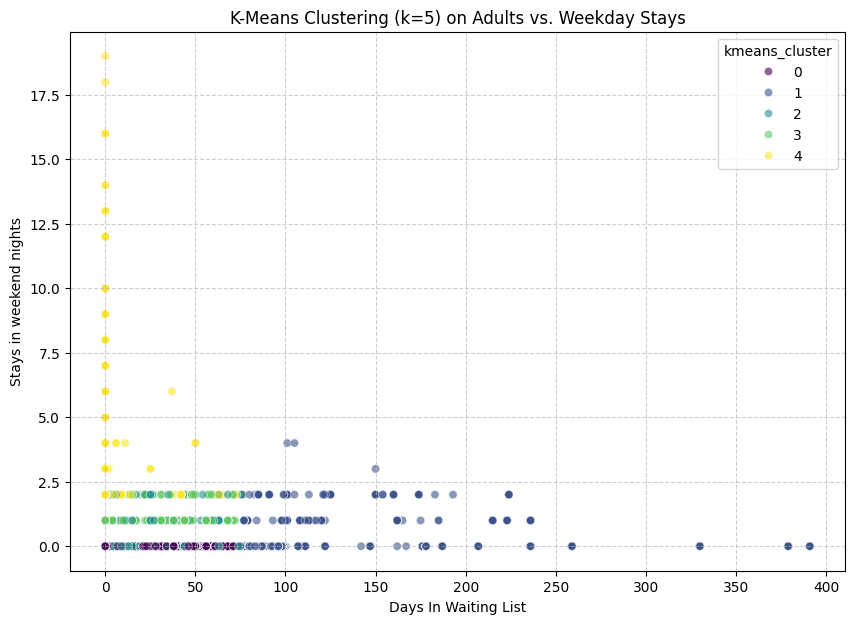

In [26]:

k = 5
kmeans_model = KMeans(n_clusters=k, random_state=42, n_init=10)
kmeans_model.fit(scaled_features_df)

clusters = kmeans_model.predict(scaled_features_df)
features_for_scaling_with_clusters = features_for_scaling.copy()
features_for_scaling_with_clusters['kmeans_cluster'] = clusters

print(f"K-Means clustering performed with k = {k} clusters.")
print("Cluster assignments have been added to 'features_for_scaling_with_clusters' DataFrame.")
plt.figure(figsize=(10, 7))
sns.scatterplot(
    x='days_in_waiting_list',
    y='stays_in_weekend_nights',
    hue='kmeans_cluster',
    data=features_for_scaling_with_clusters,
    palette='viridis',
    legend='full',
    alpha=0.6
)
plt.title(f'K-Means Clustering (k={k}) on Adults vs. Weekday Stays')
plt.xlabel('Days In Waiting List')
plt.ylabel('Stays in weekend nights')
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

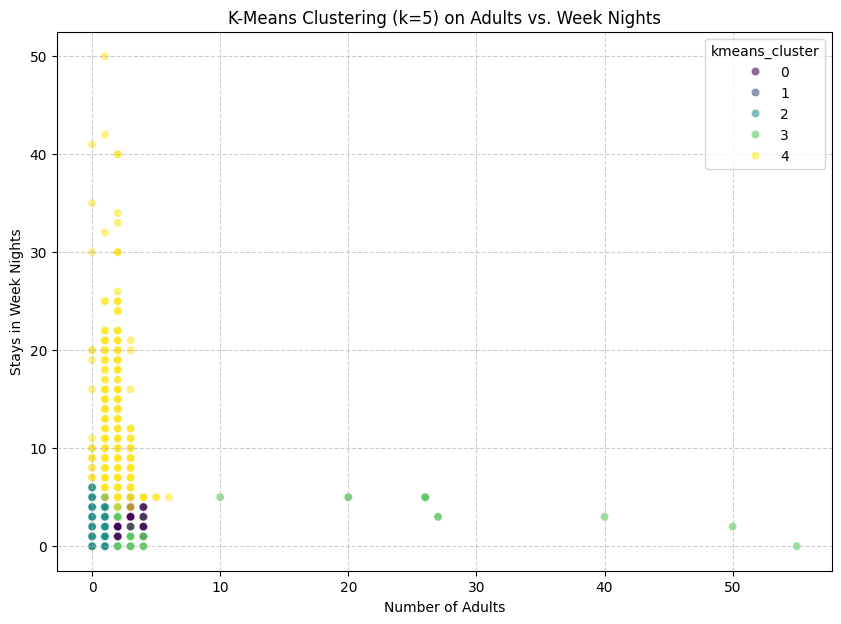

In [27]:
plt.figure(figsize=(10, 7))
sns.scatterplot(
    x='adults',
    y='stays_in_week_nights',
    hue='kmeans_cluster',
    data=features_for_scaling_with_clusters,
    palette='viridis',
    legend='full',
    alpha=0.6
)
plt.title(f'K-Means Clustering (k={k}) on Adults vs. Week Nights')
plt.xlabel('Number of Adults')
plt.ylabel('Stays in Week Nights')
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

### ✍️ Your Response: 🔧
1. I decided to make two plots and use a 5 Kmeans to allow for more defined clusters if the data allowed.

2. In both graphs there were strong concentration around the orgins but also sparce spreads vertically in both and a horizontal spread in the first plot, this tells me there might not be a super strong relationship between the variables I chose for this clustering.


## 4. Apply Gaussian Mixture Model (GMM)

### Business framing:  

Not all guests fit neatly into one cluster. GMM lets us capture uncertainty — useful if customers behave similarly across groups.

### Do the following:
- Fit a GMM with the same number of clusters you chose in Part 3
- Predict soft clusters (remember that soft clustering deals with probabilities, not labels)
- Visualize the GMM model so that you may compare it to the KMeans scatterplot

### In Your Response:
1. How did the GMM results compare to KMeans?
2. What business questions might GMM help answer better?


Gaussian Mixture Model fitted with 5 components.
Cluster assignments have been added to 'features_for_scaling_with_gmm_clusters' DataFrame.


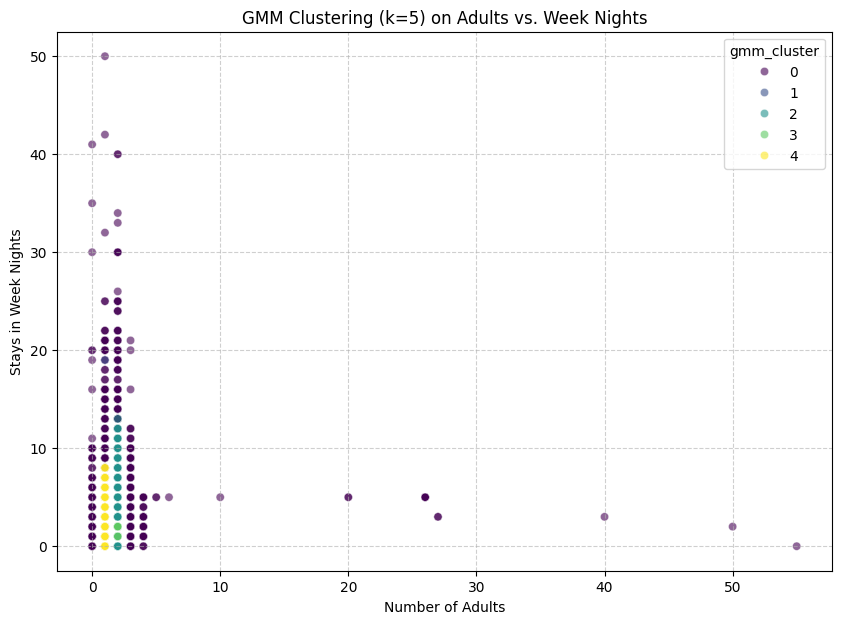

In [28]:

gmm_model = GaussianMixture(n_components=k, random_state=42)
gmm_model.fit(scaled_features_df)
gmm_clusters = gmm_model.predict(scaled_features_df)
features_for_scaling_with_gmm_clusters = features_for_scaling.copy()
features_for_scaling_with_gmm_clusters['gmm_cluster'] = gmm_clusters

print(f"Gaussian Mixture Model fitted with {k} components.")
print("Cluster assignments have been added to 'features_for_scaling_with_gmm_clusters' DataFrame.")
plt.figure(figsize=(10, 7))
sns.scatterplot(
    x='adults',
    y='stays_in_week_nights',
    hue='gmm_cluster',
    data=features_for_scaling_with_gmm_clusters,
    palette='viridis',
    legend='full',
    alpha=0.6
)
plt.title(f'GMM Clustering (k={k}) on Adults vs. Week Nights')
plt.xlabel('Number of Adults')
plt.ylabel('Stays in Week Nights')
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

### ✍️ Your Response: 🔧
1. Comparing this plot to the last, I saw more varied and populated clusters in the K means than with the GMM model

2.
Since GMM relies mroe on probablity coefficeints, they might be better in a business context with trying to conduct predictive analysis and also for making future business projections.

## 5. Evaluate Your Models

### Business framing:  

In business, models should be both useful and reliable. You’ll compare model quality using standard evaluation metrics.

### Do the following:
- Calculate the following **for each** of the models:
  - WCSS
  - Silhouette Score
  - Davies-Bouldin Index

  **NOTE:** This step may take up to 5 minutes.  It is a lot of computation time.  Please be patient.  Or you can limit the scores to using a random sample of 10K rows.

**Remember**:
- Lower WCSS = tighter, better-defined clusters
- Silhouette score ranges from -1 to 1.  Higher values = better clustering
- Lower Davies-Boulding Index = better clustering

### In Your Response:
1. Which model performed better on the metrics?
2. Would you recommend KMeans or GMM for a business analyst? Why?


In [30]:
from sklearn.metrics import silhouette_score, davies_bouldin_score

print("--- K-Means Model Evaluation ---")

kmeans_wcss = kmeans_model.inertia_
print(f"K-Means WCSS: {kmeans_wcss:.2f}")

if len(np.unique(clusters)) > 1 and len(np.unique(clusters)) < len(scaled_features_df) - 1:
    kmeans_silhouette = silhouette_score(scaled_features_df, clusters)
    print(f"K-Means Silhouette Score: {kmeans_silhouette:.4f}")
else:
    print("K-Means Silhouette Score: Cannot calculate (insufficient unique cluster labels).")

if len(np.unique(clusters)) > 1:
    kmeans_davies_bouldin = davies_bouldin_score(scaled_features_df, clusters)
    print(f"K-Means Davies-Bouldin Index: {kmeans_davies_bouldin:.4f}")
else:
    print("K-Means Davies-Bouldin Index: Cannot calculate (insufficient unique cluster labels).")

print("\n" + "="*40 + "\n")

print("--- GMM Model Evaluation ---")

gmm_centroids = gmm_model.means_

gmm_wcss = 0
for i in range(k):
    cluster_points = scaled_features_df[gmm_clusters == i]
    if not cluster_points.empty:
        gmm_wcss += ((cluster_points - gmm_centroids[i])**2).sum().sum()
print(f"GMM WCSS (Approximation): {gmm_wcss:.2f}")

if len(np.unique(gmm_clusters)) > 1 and len(np.unique(gmm_clusters)) < len(scaled_features_df) - 1:
    gmm_silhouette = silhouette_score(scaled_features_df, gmm_clusters)
    print(f"GMM Silhouette Score: {gmm_silhouette:.4f}")
else:
    print("GMM Silhouette Score: Cannot calculate (insufficient unique cluster labels).")

if len(np.unique(gmm_clusters)) > 1:
    gmm_davies_bouldin = davies_bouldin_score(scaled_features_df, gmm_clusters)
    print(f"GMM Davies-Bouldin Index: {gmm_davies_bouldin:.4f}")
else:
    print("GMM Davies-Bouldin Index: Cannot calculate (insufficient unique cluster labels).")

--- K-Means Model Evaluation ---
K-Means WCSS: 193872.83
K-Means Silhouette Score: 0.4251
K-Means Davies-Bouldin Index: 0.8623


--- GMM Model Evaluation ---
GMM WCSS (Approximation): 273466.99
GMM Silhouette Score: 0.3607
GMM Davies-Bouldin Index: 1.5752


### ✍️ Your Response: 🔧
1.
Based on the calcualtions the K-Mean seems to have better results and better clustering comapred with the GMM output.
2. For those reasons I think in a applicable business context a K-mean model would offer better insight due to the slightly better clustering characterisitics with out selected variables.


## 6. Business Interpretation

### Business framing:  

What do these clusters mean in the real world? Could they represent solo travelers, families, or bargain shoppers?

### Do the following:
- Display the characteristics of each cluster (e.g. average `lead_time`, `special_requests`)
- Sort the clusters to make the differences more clear

### In Your Response:
1. What do the segments represent in terms of guest behavior?
2. How could the hotel tailor services or promotions to each group?


In [31]:
# Calculate the mean of each feature for each K-Means cluster
kmeans_cluster_characteristics = features_for_scaling_with_clusters.groupby('kmeans_cluster')[selected_features].mean()

# Sort the clusters by a prominent feature to make differences clear
# Let's sort by 'adults' to see how group size varies across clusters
kmeans_cluster_characteristics_sorted = kmeans_cluster_characteristics.sort_values(by='adults', ascending=True)

print("K-Means Cluster Characteristics (Sorted by Adults):")
display(kmeans_cluster_characteristics_sorted)

K-Means Cluster Characteristics (Sorted by Adults):


,days_in_waiting_list,adults,stays_in_week_nights,stays_in_weekend_nights
kmeans_cluster,,,,
2,1.320306,0.982875,1.696773,0.546932
1,145.125822,1.852796,2.599507,0.564967
4,0.254853,1.971612,5.808044,2.322763
0,1.052973,2.061489,2.206370,0.000000
3,0.664197,2.079611,1.812660,1.426221


### ✍️ Your Response: 🔧
1. In cluster 2 we see adults at a .98 which may indicated far more solo travelers than couples as we see most other clusters had number of adults around 2. suprisingly I saw high days on waitlist low stays in weekend nights in the same clusters which I would have expected the oppoiste if anything.

2. Due to one cluster showing a 145 for days on waitlist, I would say the demand for that cluster is far too high and price adjustments may be needed to correct for that.


## 7. Final Reflection

### Business framing:  

Many teams ask for "segmentation" without knowing how it works. You now have hands-on experience with two clustering techniques and how to present the results.

### In Your Response:
1. What was most challenging about unsupervised learning?
2. When would you use clustering instead of supervised models?
3. How would you explain the value of clustering to a non-technical manager?
4. How does this relate to your customized learning outcome you created in canvas?


### ✍️ Your Response: 🔧
1.
This was challenging because I haven't used clutering before, so seeing my models I wasnt sure I the models wwere done properly or if there was a better way to code it becasue I have no experience to compare it to.

2.
unsupervised clustering could be useful when the data isnt sorted very well or the variables seems un related to each other, or in the case where there is no particular target variable. The clustering method can help bring different data into a more structured format

3.
The way I would best showcase clustering is though plots on modeling, being able to visualize the effectivness is going to be more compeling than me trying to pursuade.

4.
One of my outcomes was learning new tools and methods for analyzing data, I think learning how to create cluster and model them is a very unique and useful tool especially within python.

## Submission Instructions

✅ **Before submitting:**
- Make sure all code cells are run and outputs are visible  
- All markdown questions are answered thoughtfully  
- Submit the assignment as an **HTML file** on Canvas


In [32]:
!jupyter nbconvert --to html "assignment_09_FugalEric.ipynb"

[NbConvertApp] Converting notebook assignment_09_FugalEric.ipynb to html
[NbConvertApp] WARNING | Alternative text is missing on 3 image(s).
[NbConvertApp] Writing 612077 bytes to assignment_09_FugalEric.html
